In [1]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_excel(r"C:\Users\daves\Desktop\EduFlow\eduflow\evaluator_service\evaluation\evaluation_results.xlsx")
print(df.shape)
df

(18, 11)


,Job ID,Architecture,Input Parameters,Duration,Number of Docs,Completion Time,Total Input Tokens,Total Output Tokens,Custom Matrics,Rubric - LLM,Pairwise - LLM
0,job-1774534470161,Eduflow,"{""job_id"": ""job-1774534470161"", ""callback_url""...",5,4,223,39405,9973,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none
1,job-1774534999912,Baseline 1,"{""job_id"": ""job-1774534999912"", ""callback_url""...",5,4,119,29572,5201,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
2,job-1774544649734,Baseline 2,"{""job_id"": ""job-1774544649734"", ""callback_url""...",5,4,152,38306,7520,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
3,job-1774545286253,Eduflow,"{""job_id"": ""job-1774545286253"", ""callback_url""...",5,4,214,38608,9541,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none
4,job-1774545754239,Baseline 1,"{""job_id"": ""job-1774545754239"", ""callback_url""...",5,4,106,27969,4850,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
5,job-1774547498894,Baseline 2,"{""job_id"": ""job-1774547498894"", ""callback_url""...",5,4,151,36614,7286,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
6,job-1774548177351,Eduflow,"{""job_id"": ""job-1774548177351"", ""callback_url""...",5,4,227,40186,9799,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none
7,job-1774548651030,Baseline 1,"{""job_id"": ""job-1774548651030"", ""callback_url""...",5,4,110,29479,4735,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
8,job-1774549026730,Baseline 2,"{""job_id"": ""job-1774549026730"", ""callback_url""...",5,4,153,38132,7318,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
9,job-1774574045744,Eduflow,"{""job_id"": ""job-1774574045744"", ""callback_url""...",5,4,224,40286,10107,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none


In [3]:
print(df.dtypes)

Job ID                 object
Architecture           object
Input Parameters       object
Duration                int64
Number of Docs          int64
Completion Time         int64
Total Input Tokens      int64
Total Output Tokens     int64
Custom Matrics         object
Rubric - LLM           object
Pairwise - LLM         object
dtype: object


In [4]:
df["Set"] = (df.index // 3) + 1
print(df[["Set", "Job ID", "Architecture"]])

    Set             Job ID Architecture
0     1  job-1774534470161      Eduflow
1     1  job-1774534999912   Baseline 1
2     1  job-1774544649734   Baseline 2
3     2  job-1774545286253      Eduflow
4     2  job-1774545754239   Baseline 1
5     2  job-1774547498894   Baseline 2
6     3  job-1774548177351      Eduflow
7     3  job-1774548651030   Baseline 1
8     3  job-1774549026730   Baseline 2
9     4  job-1774574045744      Eduflow
10    4  job-1774574325545   Baseline 1
11    4  job-1774574626655   Baseline 2
12    5  job-1774590551422      Eduflow
13    5  job-1774584736262   Baseline 1
14    5  job-1774584969330   Baseline 2
15    6  job-1774596210500      Eduflow
16    6  job-1774595522117   Baseline 1
17    6  job-1774596683553   Baseline 2


In [5]:
def safe_parse(val):
    try:
        return json.loads(val)
    except:
        return None

df["rubric_parsed"]   = df["Rubric - LLM"].apply(safe_parse)
df["pairwise_parsed"] = df["Pairwise - LLM"].apply(safe_parse)
df["custom_parsed"]   = df["Custom Matrics"].apply(safe_parse)

# Quick check — show what we got
for col in ["rubric_parsed", "pairwise_parsed", "custom_parsed"]:
    none_count = df[col].isna().sum()
    print(f"{col}: {18 - none_count} parsed, {none_count} failed/null")

rubric_parsed: 18 parsed, 0 failed/null
pairwise_parsed: 12 parsed, 6 failed/null
custom_parsed: 18 parsed, 0 failed/null


In [6]:
# Extract rubric scores
df["rubric_overall_mean"] = df["rubric_parsed"].apply(lambda x: x.get("overall_mean") if x else None)
df["rubric_coherence"] = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("coherence") if x else None)
df["rubric_dependency_flow"] = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("dependency_flow") if x else None)
df["rubric_content_progression"] = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("content_progression") if x else None)
df["rubric_non_redundancy"] = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("non_redundancy") if x else None)

# Extract pairwise result
df["pairwise_winner"] = df["pairwise_parsed"].apply(lambda x: x.get("winner") if x else None)
df["pairwise_consensus"] = df["pairwise_parsed"].apply(lambda x: x.get("consensus") if x else None)

# Extract custom metrics — print keys first so we know what's inside
print(df["custom_parsed"][0].keys())

dict_keys(['document_count', 'metrics'])


In [7]:
print(df["custom_parsed"][0]["metrics"].keys())
print()
print(df["custom_parsed"][0]["metrics"])

dict_keys(['scaffolding_connectivity_score', 'concept_progression_velocity', 'long_range_scaffolding_depth'])

{'scaffolding_connectivity_score': {'overall': 0.5333, 'per_doc': [{'doc_id': 2, 'assumptions_count': 15, 'satisfied_count': 8, 'unsatisfied_concepts': ['M-item categories', 'Care Compare quality measures', 'Value-Based Purchasing outcomes', 'CMS Quarterly OASIS Q&As', 'Direct observation for assessment', 'Legal attestation in documentation', '50% rule for patient variability']}, {'doc_id': 3, 'assumptions_count': 15, 'satisfied_count': 9, 'unsatisfied_concepts': ['Risk stratification', 'CMS quality measures', 'Value-based purchasing initiatives', 'Skilled nursing interventions', 'Medical necessity documentation', 'Care plan goal setting']}, {'doc_id': 4, 'assumptions_count': 15, 'satisfied_count': 7, 'unsatisfied_concepts': ['CMS quality measures', 'value-based purchasing outcomes', 'Care Compare ratings', 'process measures for care coordination', 'utilization measures for he

In [8]:
# Extract custom metric scores
df["scs_overall"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["scaffolding_connectivity_score"].get("overall") if x else None
)
df["cpv"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["concept_progression_velocity"].get("cpv") if x else None
)
df["lrsd_total_depth"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["long_range_scaffolding_depth"].get("total_depth") if x else None
)
df["lrsd_avg_depth"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["long_range_scaffolding_depth"].get("average_depth") if x else None
)
df["lrsd_long_range_links"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["long_range_scaffolding_depth"].get("long_range_links") if x else None
)

# Check results
df[["Architecture", "Set", "scs_overall", "cpv", "lrsd_total_depth", "lrsd_avg_depth", "lrsd_long_range_links"]]

,Architecture,Set,scs_overall,cpv,lrsd_total_depth,lrsd_avg_depth,lrsd_long_range_links
0,Eduflow,1,0.5333,0.9872,15,1.6667,4
1,Baseline 1,1,0.7778,0.9615,10,1.2500,1
2,Baseline 2,1,0.8947,0.9605,19,1.2667,4
3,Eduflow,2,0.5111,0.8846,23,1.6429,6
4,Baseline 1,2,0.4211,0.9315,19,1.9000,7
5,Baseline 2,2,0.3778,1.0000,7,2.3333,2
6,Eduflow,3,0.5581,1.0000,21,1.5000,7
7,Baseline 1,3,0.5750,0.9865,15,1.6667,4
8,Baseline 2,3,0.6000,0.9733,21,1.9091,7
9,Eduflow,4,0.5909,0.9481,22,1.6923,6


In [9]:
# Mean and std per criterion
df["rubric_coherence_mean"] = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("coherence") if x else None)
df["rubric_dependency_flow_mean"] = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("dependency_flow") if x else None)
df["rubric_content_progression_mean"] = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("content_progression") if x else None)
df["rubric_non_redundancy_mean"] = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("non_redundancy") if x else None)

df["rubric_coherence_std"] = df["rubric_parsed"].apply(lambda x: x["std_scores"].get("coherence") if x else None)
df["rubric_dependency_flow_std"]  = df["rubric_parsed"].apply(lambda x: x["std_scores"].get("dependency_flow") if x else None)
df["rubric_content_progression_std"] = df["rubric_parsed"].apply(lambda x: x["std_scores"].get("content_progression") if x else None)
df["rubric_non_redundancy_std"] = df["rubric_parsed"].apply(lambda x: x["std_scores"].get("non_redundancy") if x else None)

# Per run scores
for run_idx in range(3):
    run_num = run_idx + 1
    df[f"rubric_run{run_num}_coherence"] = df["rubric_parsed"].apply(lambda x: x["run_details"][run_idx]["scores"].get("coherence") if x else None)
    df[f"rubric_run{run_num}_dependency_flow"] = df["rubric_parsed"].apply(lambda x: x["run_details"][run_idx]["scores"].get("dependency_flow") if x else None)
    df[f"rubric_run{run_num}_content_progression"] = df["rubric_parsed"].apply(lambda x: x["run_details"][run_idx]["scores"].get("content_progression") if x else None)
    df[f"rubric_run{run_num}_non_redundancy"] = df["rubric_parsed"].apply(lambda x: x["run_details"][run_idx]["scores"].get("non_redundancy") if x else None)

# Display mean + std
df[["Architecture", "Set",
    "rubric_overall_mean",
    "rubric_coherence_mean",     "rubric_coherence_std",
    "rubric_dependency_flow_mean","rubric_dependency_flow_std",
    "rubric_content_progression_mean", "rubric_content_progression_std",
    "rubric_non_redundancy_mean", "rubric_non_redundancy_std"]]

,Architecture,Set,rubric_overall_mean,rubric_coherence_mean,rubric_coherence_std,rubric_dependency_flow_mean,rubric_dependency_flow_std,rubric_content_progression_mean,rubric_content_progression_std,rubric_non_redundancy_mean,rubric_non_redundancy_std
0,Eduflow,1,4.75,5.0,0.0,5.0,0.0,5.00,0.00,4.00,0.00
1,Baseline 1,1,4.00,4.0,0.0,4.0,0.0,5.00,0.00,3.00,0.00
2,Baseline 2,1,4.00,4.0,0.0,4.0,0.0,5.00,0.00,3.00,0.00
3,Eduflow,2,4.83,5.0,0.0,5.0,0.0,5.00,0.00,4.33,0.47
4,Baseline 1,2,4.00,4.0,0.0,4.0,0.0,5.00,0.00,3.00,0.00
5,Baseline 2,2,4.00,4.0,0.0,4.0,0.0,5.00,0.00,3.00,0.00
6,Eduflow,3,4.75,5.0,0.0,5.0,0.0,5.00,0.00,4.00,0.00
7,Baseline 1,3,4.00,4.0,0.0,4.0,0.0,5.00,0.00,3.00,0.00
8,Baseline 2,3,3.92,4.0,0.0,4.0,0.0,4.67,0.47,3.00,0.00
9,Eduflow,4,4.75,5.0,0.0,5.0,0.0,5.00,0.00,4.00,0.00


In [10]:
metrics = ["scs_overall", "cpv", "lrsd_total_depth", "lrsd_avg_depth", "lrsd_long_range_links", 
           "rubric_overall_mean", "rubric_coherence", "rubric_dependency_flow", 
           "rubric_content_progression", "rubric_non_redundancy"]

summary = df.groupby("Architecture")[metrics].mean().round(4)
summary

,scs_overall,cpv,lrsd_total_depth,lrsd_avg_depth,lrsd_long_range_links,rubric_overall_mean,rubric_coherence,rubric_dependency_flow,rubric_content_progression,rubric_non_redundancy
Architecture,,,,,,,,,,
Baseline 1,0.5702,0.9562,15.6667,1.7741,4.5000,3.9717,4.0,4.0,4.8883,3.0000
Baseline 2,0.6511,0.9560,18.1667,1.7725,5.1667,3.8617,4.0,4.0,4.4450,3.0000
Eduflow,0.5767,0.9464,21.5000,1.6763,6.1667,4.8050,5.0,5.0,5.0000,4.2217


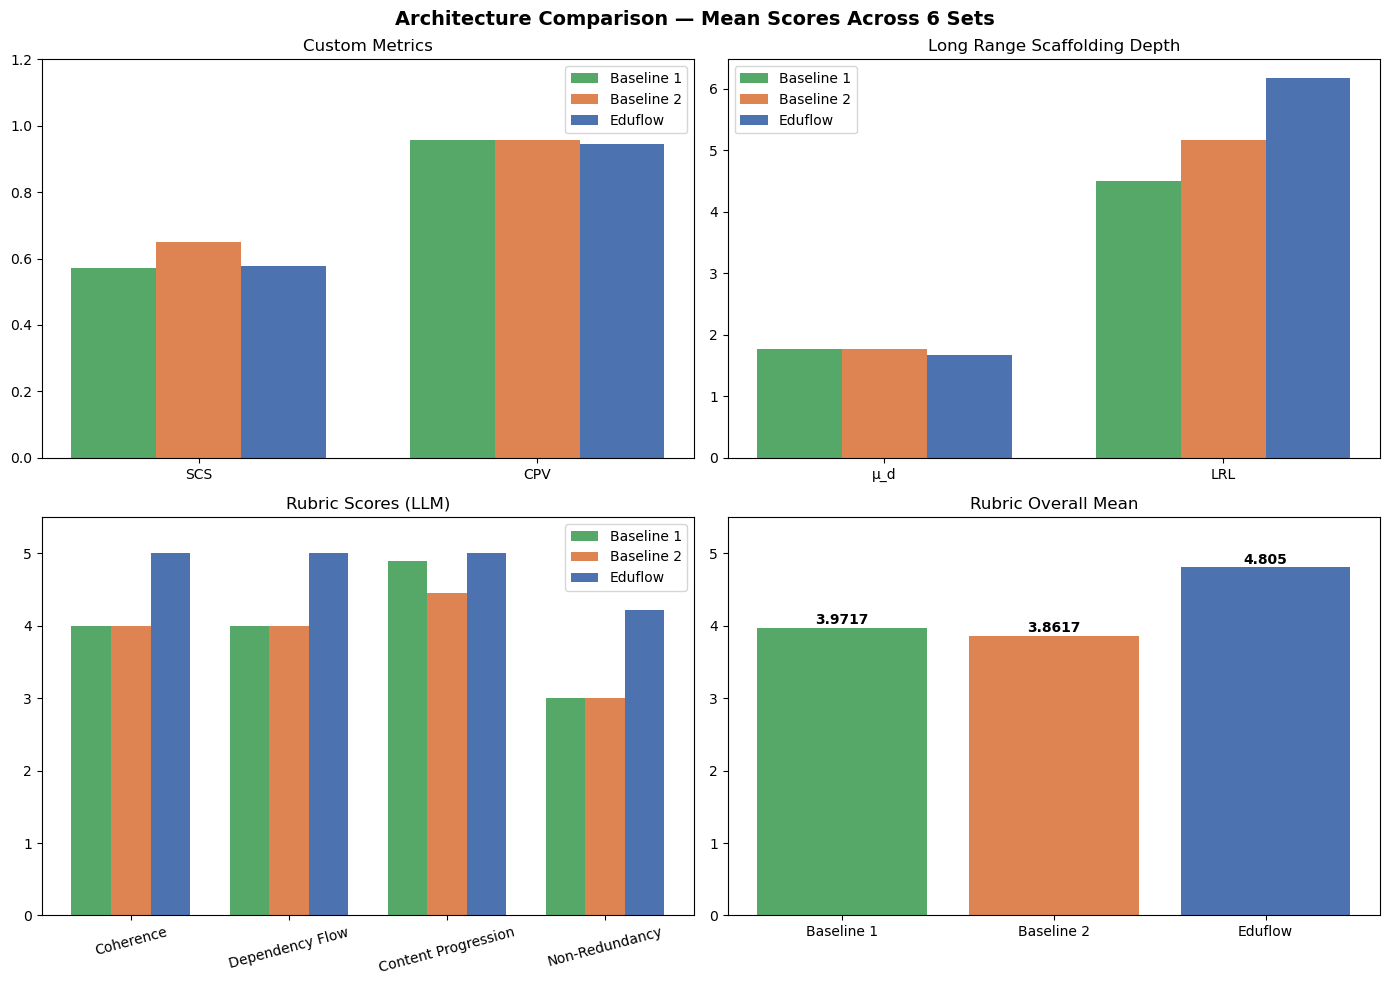

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Architecture Comparison — Mean Scores Across 6 Sets", fontsize=14, fontweight="bold")

architectures = summary.index.tolist()
colors = ["#55A868", "#DD8452", "#4C72B0"]
width = 0.25


# --- Plot 2: Custom Metrics ---
ax2 = axes[0, 0]
custom_cols = ["scs_overall", "cpv"]
custom_labels = ["SCS", "CPV"]
x = np.arange(len(custom_labels))
for i, (arch, color) in enumerate(zip(architectures, colors)):
    ax2.bar(x + i * width, summary.loc[arch, custom_cols], width, label=arch, color=color)
ax2.set_title("Custom Metrics")
ax2.set_xticks(x + width)
ax2.set_xticklabels(custom_labels)
ax2.set_ylim(0, 1.2)
ax2.legend()

# --- Plot 3: Long Range Scaffolding ---
ax3 = axes[0, 1]
lrsd_cols = ["lrsd_avg_depth", "lrsd_long_range_links"]
lrsd_labels = ["μ_d", "LRL"]
x = np.arange(len(lrsd_labels))
for i, (arch, color) in enumerate(zip(architectures, colors)):
    ax3.bar(x + i * width, summary.loc[arch, lrsd_cols], width, label=arch, color=color)
ax3.set_title("Long Range Scaffolding Depth")
ax3.set_xticks(x + width)
ax3.set_xticklabels(lrsd_labels)
ax3.legend()

# --- Plot 1: Rubric Scores ---
ax1 = axes[1, 0]
rubric_cols = ["rubric_coherence", "rubric_dependency_flow", "rubric_content_progression", "rubric_non_redundancy"]
rubric_labels = ["Coherence", "Dependency Flow", "Content Progression", "Non-Redundancy"]
x = np.arange(len(rubric_labels))
for i, (arch, color) in enumerate(zip(architectures, colors)):
    ax1.bar(x + i * width, summary.loc[arch, rubric_cols], width, label=arch, color=color)
ax1.set_title("Rubric Scores (LLM)")
ax1.set_xticks(x + width)
ax1.set_xticklabels(rubric_labels, rotation=15)
ax1.set_ylim(0, 5.5)
ax1.legend()

# --- Plot 4: Rubric Overall Mean ---
ax4 = axes[1, 1]
ax4.bar(architectures, summary["rubric_overall_mean"], color=colors)
ax4.set_title("Rubric Overall Mean")
ax4.set_ylim(0, 5.5)
for i, v in enumerate(summary["rubric_overall_mean"]):
    ax4.text(i, v + 0.05, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [90]:
# ── Pairwise Evaluation Detail (corrected score mapping) ─────────────────────
pw_df = df[df["pairwise_parsed"].notna()].copy()

criteria = ["coherence", "dependency_flow", "content_progression", "non_redundancy"]

rows = []
for _, row in pw_df.iterrows():
    p = row["pairwise_parsed"]
    win_counts = p.get("win_counts", {})
    win_rate   = p.get("win_rate", {})
    all_runs   = p.get("run_details", [])

    # Accumulate scores per actual sequence (not X/Y position)
    score_accum = {"sequence_a": {c: [] for c in criteria},
                   "sequence_b": {c: [] for c in criteria}}

    for run in all_runs:
        order = run.get("order_shown", [])   # e.g. ["sequence_b", "sequence_a"]
        # X = first shown, Y = second shown
        x_seq = order[0]   # actual sequence in X position
        y_seq = order[1]   # actual sequence in Y position

        for c in criteria:
            cs = run.get("criteria_scores", {}).get(c, {})
            if "X" in cs and "Y" in cs:
                score_accum[x_seq][c].append(cs["X"])
                score_accum[y_seq][c].append(cs["Y"])

    # Average per actual sequence
    avg = {}
    for seq in ["sequence_a", "sequence_b"]:
        for c in criteria:
            vals = score_accum[seq][c]
            avg[f"{c}_{seq}"] = round(sum(vals) / len(vals), 2) if vals else None

    rows.append({
        "Set"              : row["Set"],
        "Architecture"     : row["Architecture"],
        "Winner"           : p.get("winner"),
        "Win Count – seq_a": win_counts.get("sequence_a"),
        "Win Count – seq_b": win_counts.get("sequence_b"),
        "Ties"             : win_counts.get("tie"),
        "Win Rate – seq_a" : win_rate.get("sequence_a"),
        "Win Rate – seq_b" : win_rate.get("sequence_b"),
        **avg,
        "Consensus"        : p.get("consensus"),
    })

pw_detail = pd.DataFrame(rows).sort_values(["Set", "Architecture"]).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
print(pw_detail.to_string(index=False))

 Set Architecture     Winner  Win Count – seq_a  Win Count – seq_b  Ties  Win Rate – seq_a  Win Rate – seq_b  coherence_sequence_a  dependency_flow_sequence_a  content_progression_sequence_a  non_redundancy_sequence_a  coherence_sequence_b  dependency_flow_sequence_b  content_progression_sequence_b  non_redundancy_sequence_b                          Consensus
   1   Baseline 1 sequence_a                  3                  0     0               1.0               0.0                   5.0                         5.0                             5.0                       4.67                  3.67                        3.67                            3.67                       3.33 sequence_a wins with 100% win rate
   1   Baseline 2 sequence_a                  3                  0     0               1.0               0.0                   5.0                         5.0                             5.0                       5.00                  3.00                        3.00         

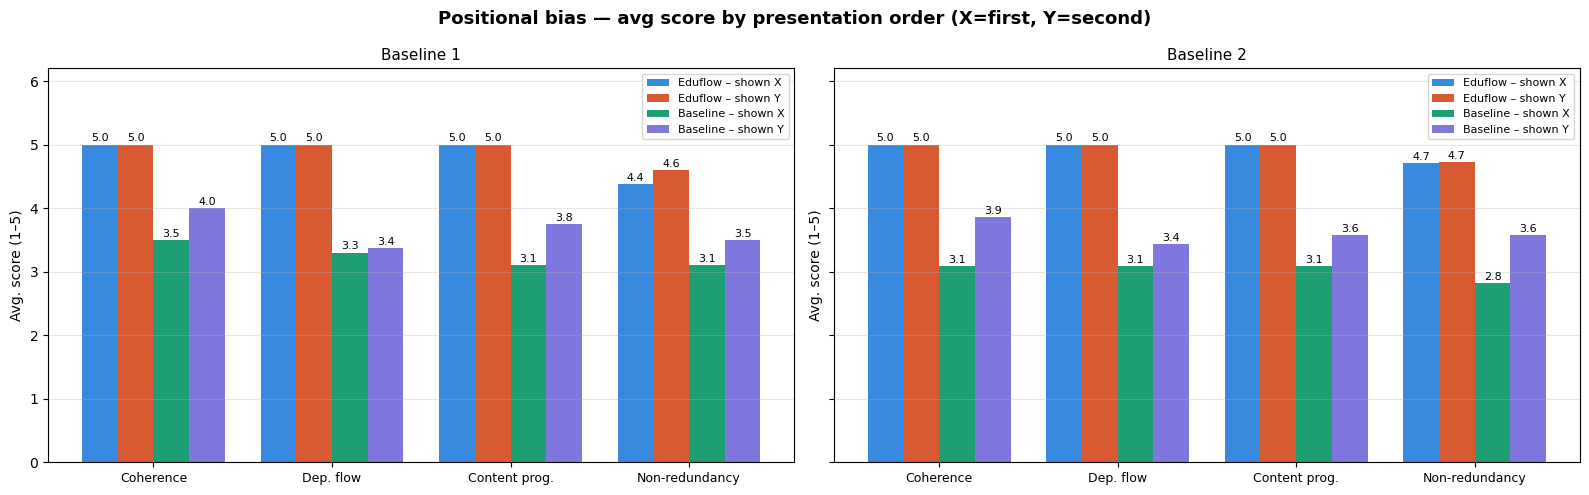

In [95]:
import matplotlib.pyplot as plt
import numpy as np

criteria = ["coherence", "dependency_flow", "content_progression", "non_redundancy"]
crit_labels = ["Coherence", "Dep. flow", "Content prog.", "Non-redundancy"]
architectures = ["Baseline 1", "Baseline 2"]
sequences = ["sequence_a", "sequence_b"]
seq_labels = {"sequence_a": "Eduflow", "sequence_b": "Baseline"}
colors = {
    ("sequence_a", "X"): "#378ADD",
    ("sequence_a", "Y"): "#D85A30",
    ("sequence_b", "X"): "#1D9E75",
    ("sequence_b", "Y"): "#7F77DD",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
fig.suptitle("Positional bias — avg score by presentation order (X=first, Y=second)", fontsize=13, fontweight="bold")

for ax, arch in zip(axes, architectures):
    arch_rows = pw_df[pw_df["Architecture"] == arch]

    # Accumulate scores per sequence per position
    pos_scores = {seq: {"X": {c: [] for c in criteria},
                        "Y": {c: [] for c in criteria}} for seq in sequences}

    for _, row in arch_rows.iterrows():
        for run in row["pairwise_parsed"].get("run_details", []):
            order = run["order_shown"]
            x_seq, y_seq = order[0], order[1]
            cs = run.get("criteria_scores", {})
            for c in criteria:
                if c not in cs:
                    continue
                pos_scores[x_seq]["X"][c].append(cs[c]["X"])
                pos_scores[y_seq]["Y"][c].append(cs[c]["Y"])

    x = np.arange(len(criteria))
    w = 0.2
    offsets = {"sequence_a_X": -1.5, "sequence_a_Y": -0.5,
               "sequence_b_X":  0.5, "sequence_b_Y":  1.5}

    for seq in sequences:
        for pos in ["X", "Y"]:
            avgs = [np.mean(pos_scores[seq][pos][c]) if pos_scores[seq][pos][c] else 0
                    for c in criteria]
            offset = offsets[f"{seq}_{pos}"]
            bars = ax.bar(x + offset * w, avgs, w,
                          label=f"{seq_labels[seq]} – shown {pos}",
                          color=colors[(seq, pos)])
            for i, v in enumerate(avgs):
                ax.text(x[i] + offset * w, v + 0.05, f"{v:.1f}",
                        ha="center", fontsize=8)

    ax.set_title(arch, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(crit_labels, fontsize=9)
    ax.set_ylim(0, 6.2)
    ax.set_ylabel("Avg. score (1–5)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

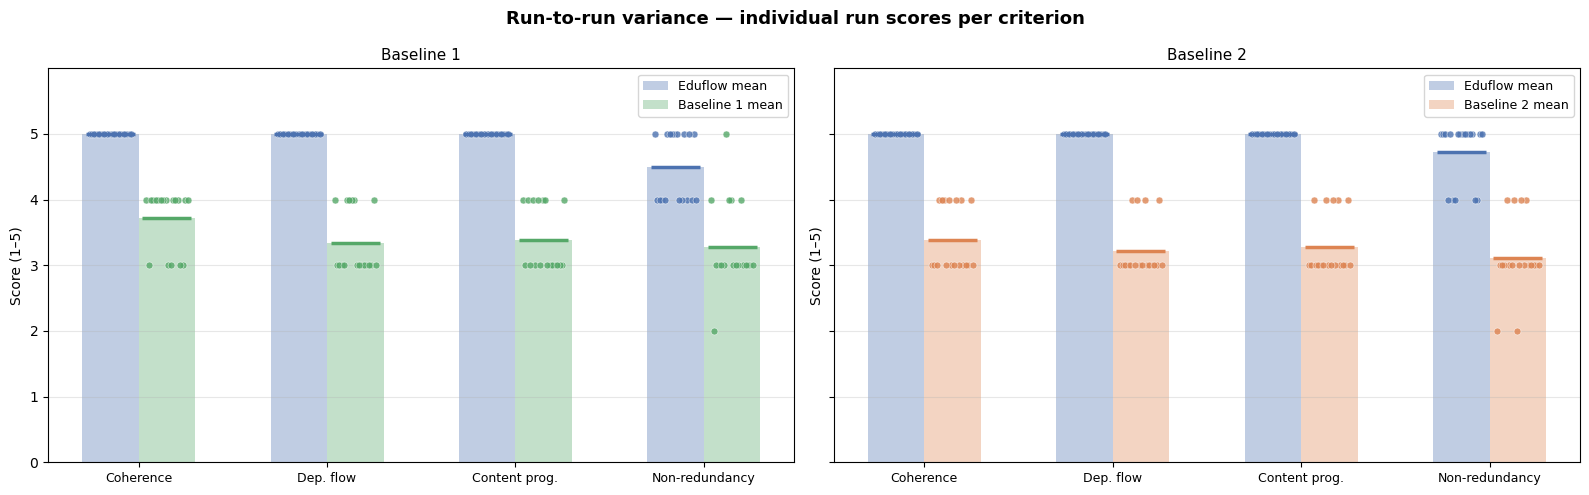

In [99]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

criteria = ["coherence", "dependency_flow", "content_progression", "non_redundancy"]
crit_labels = ["Coherence", "Dep. flow", "Content prog.", "Non-redundancy"]
architectures = ["Baseline 1", "Baseline 2"]

# Match your existing palette
arch_colors = {"Baseline 1": "#55A868", "Baseline 2": "#DD8452"}
eduflow_color = "#4C72B0"

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
fig.suptitle("Run-to-run variance — individual run scores per criterion", fontsize=13, fontweight="bold")

for ax, arch in zip(axes, architectures):
    arch_rows = pw_df[pw_df["Architecture"] == arch]

    records = []
    for _, row in arch_rows.iterrows():
        for run in row["pairwise_parsed"].get("run_details", []):
            order = run["order_shown"]
            x_seq, y_seq = order[0], order[1]
            cs = run.get("criteria_scores", {})
            for c in criteria:
                if c not in cs:
                    continue
                a_score = cs[c]["X"] if x_seq == "sequence_a" else cs[c]["Y"]
                b_score = cs[c]["X"] if x_seq == "sequence_b" else cs[c]["Y"]
                records.append({
                    "set": row["Set"], "run": run["run"],
                    "criterion": c, "seq_a": a_score, "seq_b": b_score,
                })

    rec_df = pd.DataFrame(records)
    x = np.arange(len(criteria))
    w = 0.3

    seq_config = {
        "seq_a": {"label": "Eduflow", "color": eduflow_color,      "offset": -w / 2},
        "seq_b": {"label": arch,      "color": arch_colors[arch],  "offset":  w / 2},
    }

    for seq, cfg in seq_config.items():
        means = [rec_df[rec_df["criterion"] == c][seq].mean() for c in criteria]
        ax.bar(x + cfg["offset"], means, w, color=cfg["color"],
               alpha=0.35, label=f"{cfg['label']} mean")

        for i, c in enumerate(criteria):
            scores = rec_df[rec_df["criterion"] == c][seq].values
            jitter = np.linspace(-w/2 + 0.04, w/2 - 0.04, len(scores))
            np.random.seed(42)
            np.random.shuffle(jitter)
            for j, score in enumerate(scores):
                ax.scatter(x[i] + cfg["offset"] + jitter[j], score,
                           color=cfg["color"], s=25, zorder=5,
                           edgecolors="white", linewidths=0.4, alpha=0.8)

        for i, m in enumerate(means):
            ax.hlines(m, x[i] + cfg["offset"] - w/2 + 0.02,
                      x[i] + cfg["offset"] + w/2 - 0.02,
                      colors=cfg["color"], linewidths=2.5, zorder=6)

    ax.set_title(arch, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(crit_labels, fontsize=9)
    ax.set_ylim(0, 6)
    ax.set_yticks(range(6))
    ax.set_ylabel("Score (1–5)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [92]:
# ── Extract per-run data for bias & variance analysis ──────────────────────
pw_df = df[df["pairwise_parsed"].notna()].copy()
criteria = ["coherence", "dependency_flow", "content_progression", "non_redundancy"]

run_rows = []
for _, row in pw_df.iterrows():
    p = row["pairwise_parsed"]
    for run in p.get("run_details", []):
        order = run.get("order_shown", [])
        x_seq, y_seq = order[0], order[1]
        cs = run.get("criteria_scores", {})
        for c in criteria:
            if c in cs:
                run_rows.append({
                    "Set": row["Set"],
                    "Architecture": row["Architecture"],
                    "Run": run["run"],
                    "Criterion": c,
                    "sequence_a_score": cs[c]["X"] if x_seq == "sequence_a" else cs[c]["Y"],
                    "sequence_b_score": cs[c]["X"] if x_seq == "sequence_b" else cs[c]["Y"],
                    "eduflow_position": "X (first)" if x_seq == "sequence_a" else "Y (second)",
                    "eduflow_score_by_pos": cs[c]["Y"] if x_seq == "sequence_b" else cs[c]["X"],
                    "baseline_score_by_pos": cs[c]["X"] if x_seq == "sequence_b" else cs[c]["Y"],
                })

run_df = pd.DataFrame(run_rows)
print(run_df.head(12).to_string(index=False))

 Set Architecture  Run           Criterion  sequence_a_score  sequence_b_score eduflow_position  eduflow_score_by_pos  baseline_score_by_pos
   1   Baseline 1    1           coherence                 5                 4        X (first)                     5                      4
   1   Baseline 1    1     dependency_flow                 5                 4        X (first)                     5                      4
   1   Baseline 1    1 content_progression                 5                 4        X (first)                     5                      4
   1   Baseline 1    1      non_redundancy                 5                 4        X (first)                     5                      4
   1   Baseline 1    2           coherence                 5                 3       Y (second)                     5                      3
   1   Baseline 1    2     dependency_flow                 5                 3       Y (second)                     5                      3
   1   Baseli

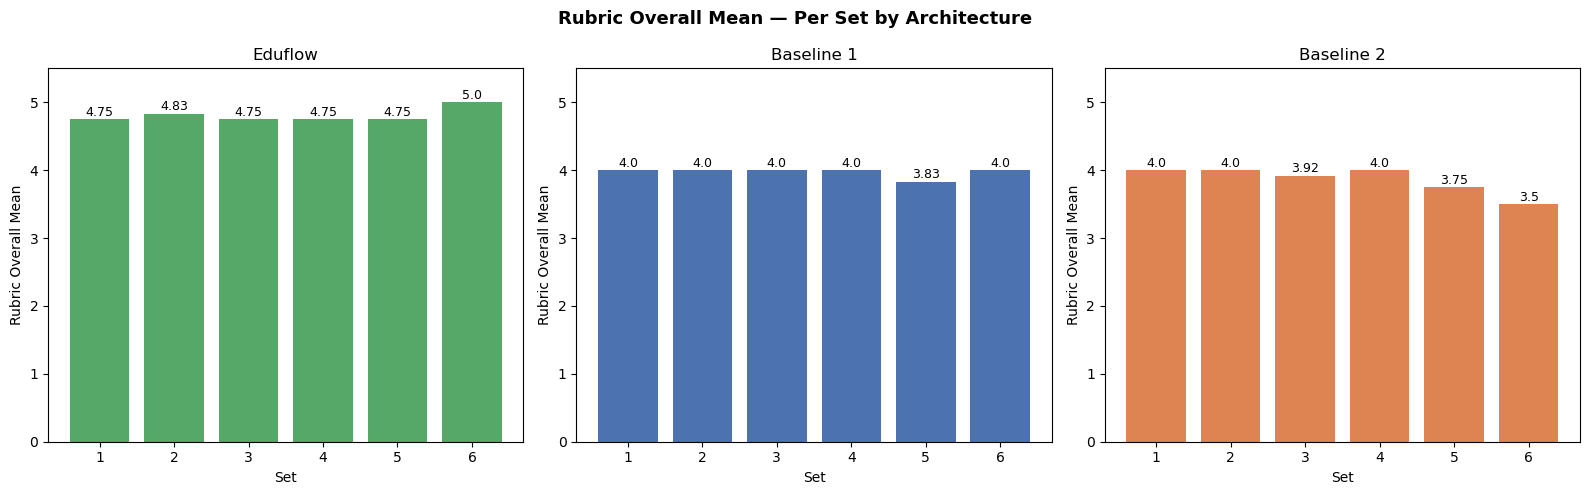

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Rubric Overall Mean — Per Set by Architecture", fontsize=13, fontweight="bold")

colors = {"Eduflow": "#55A868", "Baseline 1": "#4C72B0", "Baseline 2": "#DD8452"}
sets = [1, 2, 3, 4, 5, 6]

for ax, arch in zip(axes, ["Eduflow", "Baseline 1", "Baseline 2"]):
    subset = df[df["Architecture"] == arch].sort_values("Set")
    ax.bar(subset["Set"], subset["rubric_overall_mean"], color=colors[arch])
    ax.set_title(arch)
    ax.set_xlabel("Set")
    ax.set_ylabel("Rubric Overall Mean")
    ax.set_ylim(0, 5.5)
    ax.set_xticks(sets)
    for _, row in subset.iterrows():
        ax.text(row["Set"], row["rubric_overall_mean"] + 0.05, 
                str(round(row["rubric_overall_mean"], 2)), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [27]:
pairwise_df = df[df["pairwise_parsed"].notna()].copy()

print("Pairwise winner distribution:")
print(pairwise_df.groupby(["Architecture", "pairwise_winner"]).size())

print("\nPer set pairwise results:")
print(pairwise_df[["Set", "Architecture", "pairwise_winner", "pairwise_consensus"]])

Pairwise winner distribution:
Architecture  pairwise_winner
Baseline 1    sequence_a         6
Baseline 2    sequence_a         6
dtype: int64

Per set pairwise results:
    Set Architecture pairwise_winner                  pairwise_consensus
1     1   Baseline 1      sequence_a  sequence_a wins with 100% win rate
2     1   Baseline 2      sequence_a  sequence_a wins with 100% win rate
4     2   Baseline 1      sequence_a  sequence_a wins with 100% win rate
5     2   Baseline 2      sequence_a  sequence_a wins with 100% win rate
7     3   Baseline 1      sequence_a  sequence_a wins with 100% win rate
8     3   Baseline 2      sequence_a  sequence_a wins with 100% win rate
10    4   Baseline 1      sequence_a  sequence_a wins with 100% win rate
11    4   Baseline 2      sequence_a  sequence_a wins with 100% win rate
13    5   Baseline 1      sequence_a  sequence_a wins with 100% win rate
14    5   Baseline 2      sequence_a  sequence_a wins with 100% win rate
16    6   Baseline 1      s

In [12]:
print("Token Usage by Architecture:")
token_summary = df.groupby("Architecture")[["Total Input Tokens", "Total Output Tokens"]].agg(["mean", "sum"]).round(0)
print(token_summary)

print("\nCompletion Time by Architecture:")
print(df.groupby("Architecture")["Completion Time"].agg(["mean", "min", "max"]).round(2))

Token Usage by Architecture:
             Total Input Tokens         Total Output Tokens       
                           mean     sum                mean    sum
Architecture                                                      
Baseline 1              29660.0  177959              4755.0  28531
Baseline 2              38460.0  230760              7444.0  44662
Eduflow                 40609.0  243655             10126.0  60753

Completion Time by Architecture:
                mean  min  max
Architecture                  
Baseline 1    112.33  106  119
Baseline 2    154.00  151  157
Eduflow       225.00  214  232


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter EduFlow only
edu = df[df["Architecture"] == "Eduflow"]["Completion Time"]

# ── Stats table ──────────────────────────────────────────────────────────────
stats = pd.DataFrame({
    "Metric": ["Number of runs", "Mean generation time (s)", "Standard deviation (s)",
                "Minimum (s)", "Maximum (s)", "Range (s)"],
    "Value": [
        len(edu),
        round(edu.mean(), 2),
        round(edu.std(), 2),
        round(edu.min(), 2),
        round(edu.max(), 2),
        round(edu.max() - edu.min(), 2),
    ]
})
print(stats.to_string(index=False))

                  Metric  Value
          Number of runs   6.00
Mean generation time (s) 225.00
  Standard deviation (s)   6.39
             Minimum (s) 214.00
             Maximum (s) 232.00
               Range (s)  18.00


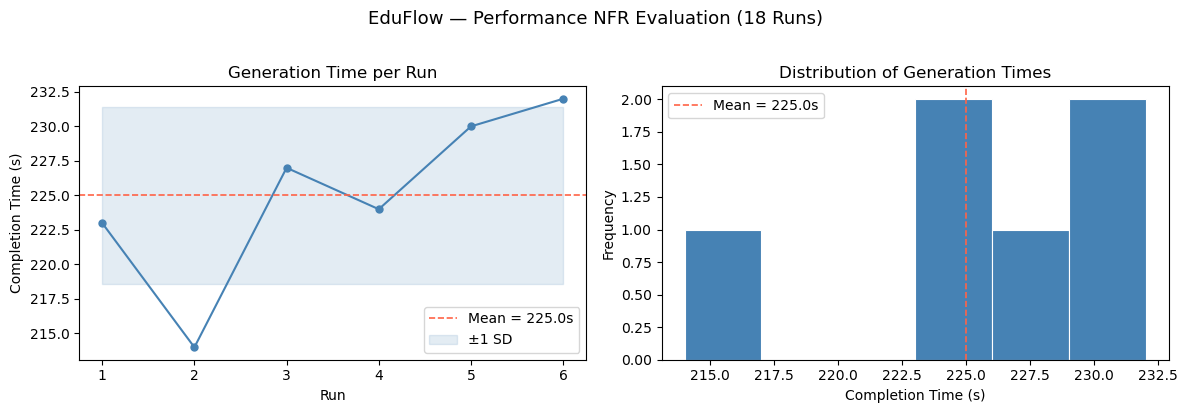

Saved: eduflow_performance.png


In [ ]:
# ── Plot 1: Generation time per run (line) ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

runs = range(1, len(edu) + 1)
axes[0].plot(runs, edu.values, marker='o', linewidth=1.5,
             color='steelblue', markersize=5)
axes[0].axhline(edu.mean(), color='tomato', linestyle='--',
                linewidth=1.2, label=f'Mean = {edu.mean():.1f}s')
axes[0].fill_between(runs,
                     edu.mean() - edu.std(),
                     edu.mean() + edu.std(),
                     alpha=0.15, color='steelblue', label='±1 SD')
axes[0].set_title('Generation Time per Run', fontsize=12)
axes[0].set_xlabel('Run')
axes[0].set_ylabel('Completion Time (s)')
axes[0].legend()
axes[0].set_xticks(list(runs))

# ── Plot 2: Distribution (histogram) ─────────────────────────────────────────
axes[1].hist(edu.values, bins=6, color='steelblue',
             edgecolor='white', linewidth=0.8)
axes[1].axvline(edu.mean(), color='tomato', linestyle='--',
                linewidth=1.2, label=f'Mean = {edu.mean():.1f}s')
axes[1].set_title('Distribution of Generation Times', fontsize=12)
axes[1].set_xlabel('Completion Time (s)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('EduFlow — Performance NFR Evaluation (18 Runs)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eduflow_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
quality = df.groupby("Architecture")[["rubric_overall_mean", "scs_overall", "cpv", "lrsd_long_range_links"]].mean().round(4)
efficiency = df.groupby("Architecture")[["Total Input Tokens", "Total Output Tokens", "Completion Time"]].mean().round(0)

final_summary = pd.concat([quality, efficiency], axis=1)
final_summary.columns = [
    "Rubric Mean", "SCS", "CPV", "LR Links",
    "Avg Input Tokens", "Avg Output Tokens", "Avg Completion Time (s)"
]

# Add pairwise win rate
final_summary["Pairwise Win Rate"] = "N/A (reference)"
final_summary.loc["Baseline 1", "Pairwise Win Rate"] = "0/6 (0%)"
final_summary.loc["Baseline 2", "Pairwise Win Rate"] = "0/6 (0%)"

print(final_summary.to_string())

              Rubric Mean     SCS     CPV  LR Links  Avg Input Tokens  Avg Output Tokens  Avg Completion Time (s) Pairwise Win Rate
Architecture                                                                                                                       
Baseline 1         3.9717  0.5702  0.9562    4.5000           29660.0             4755.0                    112.0          0/6 (0%)
Baseline 2         3.8617  0.6511  0.9560    5.1667           38460.0             7444.0                    154.0          0/6 (0%)
Eduflow            4.8050  0.5767  0.9464    6.1667           40609.0            10126.0                    225.0   N/A (reference)


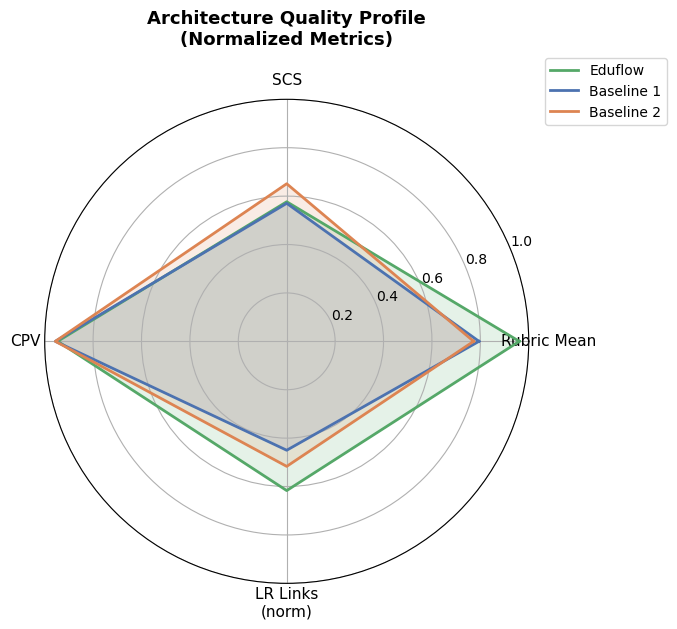

In [30]:
# Normalize metrics to 0-1 scale for radar
metrics_radar = {
    "Rubric Mean":  {"Eduflow": 4.8050/5, "Baseline 1": 3.9717/5, "Baseline 2": 3.8617/5},
    "SCS":          {"Eduflow": 0.5767,   "Baseline 1": 0.5702,   "Baseline 2": 0.6511},
    "CPV":          {"Eduflow": 0.9464,   "Baseline 1": 0.9562,   "Baseline 2": 0.9560},
    "LR Links\n(norm)": {"Eduflow": 6.1667/10, "Baseline 1": 4.5/10, "Baseline 2": 5.1667/10},
}

labels = list(metrics_radar.keys())
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

colors = {"Eduflow": "#55A868", "Baseline 1": "#4C72B0", "Baseline 2": "#DD8452"}

for arch, color in colors.items():
    values = [metrics_radar[m][arch] for m in labels]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=arch)
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Architecture Quality Profile\n(Normalized Metrics)", 
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()


In [33]:
# Extract criteria scores from pairwise results
pairwise_rows = []

for _, row in pairwise_df.iterrows():
    parsed = row["pairwise_parsed"]
    criteria_scores = parsed.get("criteria_scores", {})
    order_shown = parsed["run_details"][0]["order_shown"]  # who was sequence_a and sequence_b
    
    for run in parsed["run_details"]:
        pairwise_rows.append({
            "Set": row["Set"],
            "Baseline": row["Architecture"],
            "order_shown": run["order_shown"],
            "winner": run["winner"],
            "criteria_scores": run.get("criteria_scores", {})
        })

pairwise_detail_df = pd.DataFrame(pairwise_rows)
print(pairwise_detail_df.shape)
print(pairwise_detail_df.iloc[0])  # inspect first row

(36, 5)
Set                                                                1
Baseline                                                  Baseline 1
order_shown                                 [sequence_a, sequence_b]
winner                                                    sequence_a
criteria_scores    {'coherence': {'X': 5, 'Y': 4}, 'dependency_fl...
Name: 0, dtype: object


In [34]:
rows = []

for _, row in pairwise_detail_df.iterrows():
    order = row["order_shown"]  # e.g. ['sequence_a', 'sequence_b']
    criteria_scores = row["criteria_scores"]
    
    # sequence_a is always Eduflow (the reference)
    # X and Y depend on the order shown to the judge
    x_label = order[0]  # who was shown as X
    y_label = order[1]  # who was shown as Y
    
    for criterion, scores in criteria_scores.items():
        x_score = scores.get("X")
        y_score = scores.get("Y")
        
        # Map back to actual architecture
        eduflow_score  = x_score if x_label == "sequence_a" else y_score
        baseline_score = x_score if x_label != "sequence_a" else y_score
        
        rows.append({
            "Set":            row["Set"],
            "Baseline":       row["Baseline"],
            "Criterion":      criterion,
            "Eduflow Score":  eduflow_score,
            "Baseline Score": baseline_score,
            "Gap":            eduflow_score - baseline_score,  # positive = Eduflow better
        })

scores_df = pd.DataFrame(rows)
print(scores_df.shape)
print(scores_df.head(8))

(144, 6)
   Set    Baseline            Criterion  Eduflow Score  Baseline Score  Gap
0    1  Baseline 1            coherence              5               4    1
1    1  Baseline 1      dependency_flow              5               4    1
2    1  Baseline 1  content_progression              5               4    1
3    1  Baseline 1       non_redundancy              5               4    1
4    1  Baseline 1            coherence              5               3    2
5    1  Baseline 1      dependency_flow              5               3    2
6    1  Baseline 1  content_progression              5               3    2
7    1  Baseline 1       non_redundancy              4               2    2


In [35]:
# Average gap per criterion per baseline
gap_summary = scores_df.groupby(["Baseline", "Criterion"])[["Eduflow Score", "Baseline Score", "Gap"]].mean().round(3)
print(gap_summary)

print("\nOverall average gap (Eduflow - Baseline):")
print(scores_df.groupby("Baseline")["Gap"].mean().round(3))

print("\nHow often does Eduflow score HIGHER than baseline?")
scores_df["Eduflow Wins"] = scores_df["Gap"] > 0
scores_df["Tie"]          = scores_df["Gap"] == 0
scores_df["Baseline Wins"]= scores_df["Gap"] < 0
print(scores_df.groupby("Baseline")[["Eduflow Wins", "Tie", "Baseline Wins"]].mean().round(3))

                                Eduflow Score  Baseline Score    Gap
Baseline   Criterion                                                
Baseline 1 coherence                    5.000           3.722  1.278
           content_progression          5.000           3.389  1.611
           dependency_flow              5.000           3.333  1.667
           non_redundancy               4.500           3.278  1.222
Baseline 2 coherence                    5.000           3.389  1.611
           content_progression          5.000           3.278  1.722
           dependency_flow              5.000           3.222  1.778
           non_redundancy               4.722           3.111  1.611

Overall average gap (Eduflow - Baseline):
Baseline
Baseline 1    1.444
Baseline 2    1.681
Name: Gap, dtype: float64

How often does Eduflow score HIGHER than baseline?
            Eduflow Wins    Tie  Baseline Wins
Baseline                                      
Baseline 1         0.986  0.014            0.0

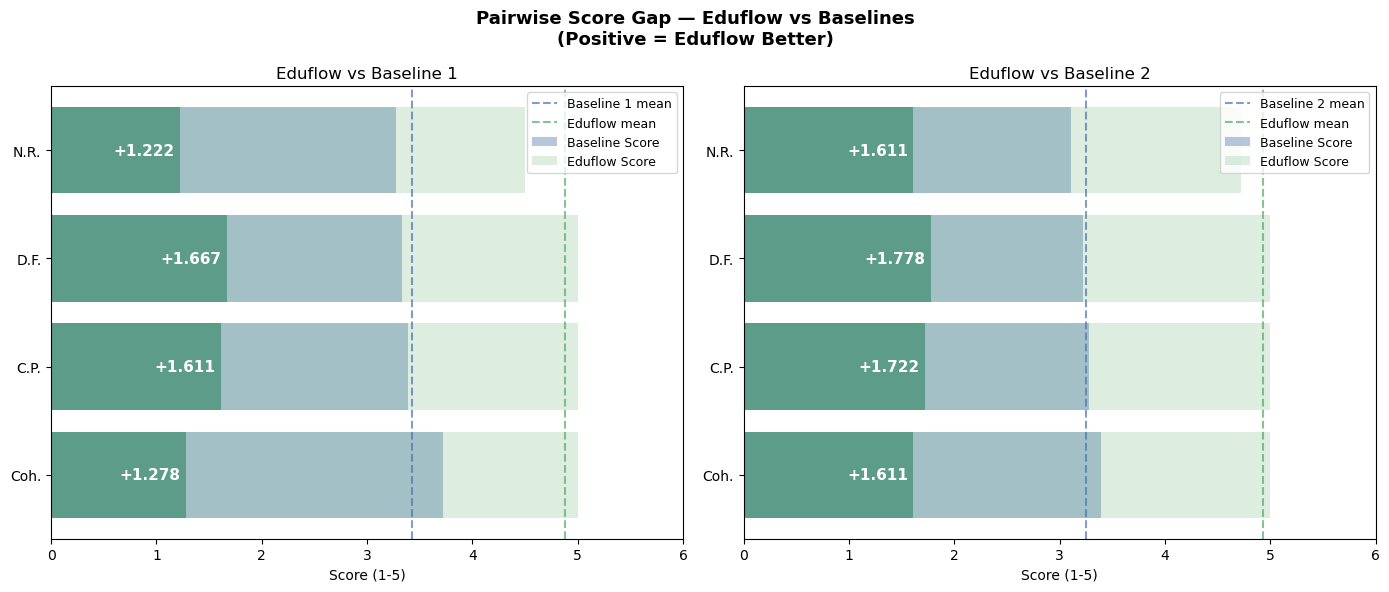

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Pairwise Score Gap — Eduflow vs Baselines\n(Positive = Eduflow Better)", 
             fontsize=13, fontweight="bold")

criteria_labels = {
    "coherence": "Coh.",
    "dependency_flow": "D.F.", 
    "content_progression": "C.P.",
    "non_redundancy": "N.R."
}

for ax, baseline in zip(axes, ["Baseline 1", "Baseline 2"]):
    subset = gap_summary.loc[baseline].reset_index()
    subset["Criterion"] = subset["Criterion"].map(criteria_labels)
    
    bars = ax.barh(subset["Criterion"], subset["Gap"], color="#55A868", alpha=0.85)
    ax.barh(subset["Criterion"], subset["Baseline Score"], 
            left=0, color="#4C72B0", alpha=0.4, label="Baseline Score")
    ax.barh(subset["Criterion"], subset["Eduflow Score"],
            left=0, color="#55A868", alpha=0.2, label="Eduflow Score")
    
    # Add gap labels
    for bar, gap in zip(bars, subset["Gap"]):
        ax.text(bar.get_width() - 0.05, bar.get_y() + bar.get_height()/2,
                f"+{gap:.3f}", va="center", ha="right", 
                fontweight="bold", color="white", fontsize=11)
    
    ax.set_title(f"Eduflow vs {baseline}")
    ax.set_xlim(0, 6)
    ax.axvline(x=subset["Baseline Score"].mean(), color="#4C72B0", 
               linestyle="--", alpha=0.7, label=f"{baseline} mean")
    ax.axvline(x=subset["Eduflow Score"].mean(), color="#55A868", 
               linestyle="--", alpha=0.7, label="Eduflow mean")
    ax.legend(fontsize=9)
    ax.set_xlabel("Score (1-5)")

plt.tight_layout()
plt.show()

In [37]:
sys.path.append(os.path.abspath("../.."))

BASE_PATH = r"C:\Users\daves\Desktop\EduFlow\eduflow\evaluator_service\evaluation\downloaded_jobs"

word_counts = []

for _, row in df.iterrows():
    job_id = row["Job ID"]
    arch = row["Architecture"]
    set_num = row["Set"]
    pdf_folder = os.path.join(BASE_PATH, job_id, "pdf")
    
    if not os.path.exists(pdf_folder):
        print(f"[{job_id}] pdf folder not found")
        continue

    pdfs = sorted([f for f in os.listdir(pdf_folder) if f.endswith(".pdf")])
    
    for pdf_file in pdfs:
        pdf_path = os.path.join(pdf_folder, pdf_file)
        # we'll use the already available extractor
        from evaluator_service.utils.pdf_extractor import extract_text_from_pdf
        text = extract_text_from_pdf(pdf_path)
        wc = len(text.split()) if text else 0
        word_counts.append({
            "Job ID": job_id,
            "Architecture": arch,
            "Set": set_num,
            "PDF": pdf_file,
            "Word Count": wc
        })

wc_df = pd.DataFrame(word_counts)
print(wc_df.groupby("Architecture")["Word Count"].agg(["mean", "min", "max"]).round(0))

                mean  min   max
Architecture                   
Baseline 1     671.0  556   759
Baseline 2     644.0  569   727
Eduflow       1120.0  856  1439


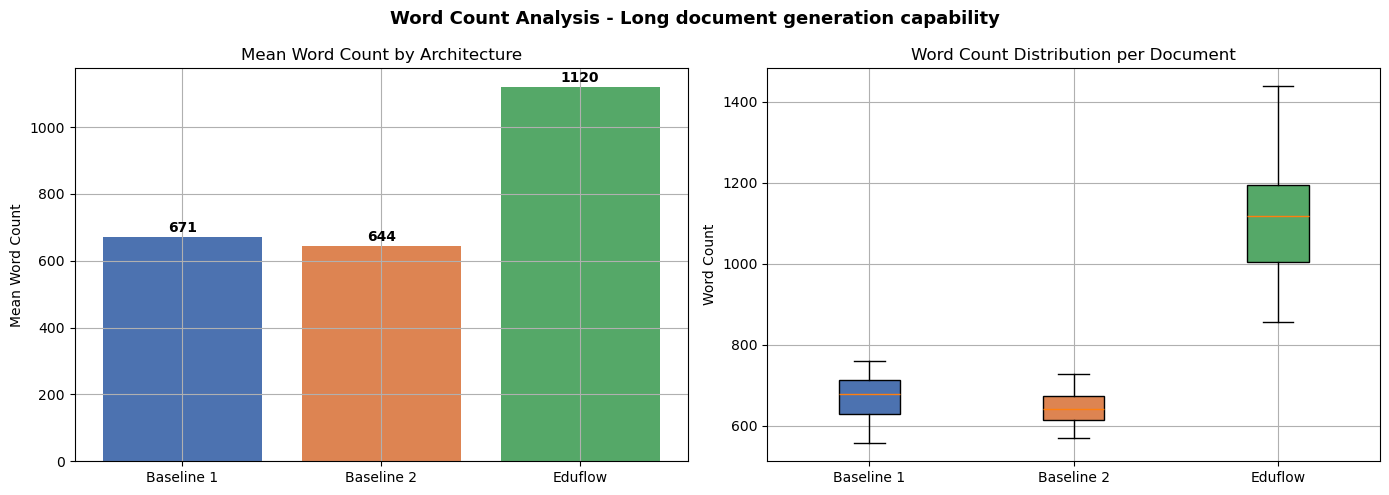

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Word Count Analysis - Long document generation capability", fontsize=13, fontweight="bold")

colors = {"Eduflow": "#55A868", "Baseline 1": "#4C72B0", "Baseline 2": "#DD8452"}

# --- Plot 1: Mean word count per architecture with target band ---
ax1 = axes[0]
ax1.grid(True)
archs = ["Baseline 1", "Baseline 2", "Eduflow"]
means = [671, 644, 1120]
ax1.bar(archs, means, color=[colors[a] for a in archs])
for i, v in enumerate(means):
    ax1.text(i, v + 15, str(v), ha="center", fontweight="bold")
ax1.set_ylabel("Mean Word Count")
ax1.set_title("Mean Word Count by Architecture")

# --- Plot 2: Per doc distribution as boxplot ---
ax2 = axes[1]
ax2.grid(True)
data_to_plot = [wc_df[wc_df["Architecture"] == arch]["Word Count"].values for arch in archs]
bp = ax2.boxplot(data_to_plot, tick_labels=archs, patch_artist=True)
for patch, arch in zip(bp["boxes"], archs):
    patch.set_facecolor(colors[arch])
ax2.set_ylabel("Word Count")
ax2.set_title("Word Count Distribution per Document")

plt.tight_layout()
plt.show()